# Hiperparametros — AC CTRL → Reactor Ciclopentanol
Se ajusta la busqueda en mejores resultados



## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1791, done.
remote: Counting objects: 100% (351/351), done.
remote: Compressing objects: 100% (235/235), done.
remote: Total 1791 (delta 210), reused 250 (delta 115), pack-reused 1440 (from 1)
Receiving objects: 100% (1791/1791), 53.46 MiB | 24.43 MiB/s, done.
Resolving deltas: 100% (1074/1074), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.Simulation_Env.Reactor_Cyclopentanol import CyclopentanolReactor
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.Simulation_Env.SimulationEnv import SimulationPIDEnv
from Agente.Actor_Critic.train_AC import ACTrainer
from Agente.Actor_Critic.algorithm_AC import ACAgent
from Agente.memory import SimpleReplayBuffer
from Agente.Actor_Critic.transfer_learning_AC import setup_transfer_learning, freeze_layers
from Aux.PIDComponents_PID import PIDController
from Aux.PIDComponents_time import ResponseTimeDetector
from Aux.PIDComponentes_translate import ApplyAction

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cpu
Device: CPU


## 2. Corrida larga: sweep 5k from scratch

In [9]:
# ============ CONFIG PRODUCCIÓN — solar-sweep-15 ganador ============

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_AC_Cyclopentanol_Prod'
RUN_NAME = 'ac_cyclopentanol_5k_V3'

N_EPISODES = 5000
EVAL_FREQUENCY = 100
LOG_FREQUENCY = 100
SAVE_FREQUENCY = 1000
EARLY_STOPPING_PATIENCE = 20
N_MANIPULABLE_VARS = 2
MANIPULABLE_RANGES = [(0.5, 1.5), (395.0, 420.0)]
ACTUATOR_LIMITS = [(50.0, 800.0), (-8500.0, 0.0)]
DT = 0.01
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED=42

trainer_config_prod = {
    'env_config': {
        'architecture':          'simple',
        'env_type':              'simulation',
        'action_type':           'continuous',
        'n_manipulable_vars':    N_MANIPULABLE_VARS,
        'manipulable_ranges':    MANIPULABLE_RANGES,
        'manipulable_setpoints': None,
        'dt_usuario':            DT,
        'max_steps':             100,
        'max_time_detector':     3.0,
        'reward_dead_band':      0.05,
        'delta_percent_ctrl':    0.05,
        'reward_weights':        {'error': 1.0, 'tiempo': 0.001, 'overshoot': 5.0, 'energy': 0.0},
        'pid_limits':            [(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
        'agent_controller_config': {'agent_type': 'continuous'},
        'env_type_config': {
            'dt': DT,
            'control_limits': (ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
        },
        'stability_config': {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio':   0.3,
            'max_abrupt_change_ratio':  0.05,
            'abrupt_change_threshold':  0.2,
        },
    },
    'agent_ctrl_config': {
        'algorithm':    'ac',
        'state_dim':    10,
        'action_dim':   6,
        'n_vars':       2,
        'action_type':  'continuous',
        'hidden_dims':  (256, 128, 64),
        'lr_actor':     3e-05,
        'lr_critic':    1e-03,
        'gamma':        0.99,
        'entropy_coef': 0.001,
        'batch_size':   128,
        'buffer_size':  50000,
        'warmup_steps': 500,
        'device':       DEVICE,
        'seed':         SEED,
    },
    'n_episodes':                    N_EPISODES,
    'eval_frequency':                EVAL_FREQUENCY,
    'log_frequency':                 LOG_FREQUENCY,
    'save_frequency':                SAVE_FREQUENCY,
    'checkpoint_dir':                f'checkpoints/{RUN_NAME}',
    'early_stopping_patience':       EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct':  0.01,
    'use_wandb': True,
}



In [10]:
# ============ CREAR ============
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

reactor_prod = CyclopentanolReactor(
    dt=DT,
    control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1])
)
trainer_prod = ACTrainer(trainer_config_prod)
trainer_prod.env.proceso.connect_external_process(reactor_prod)
trainer_prod.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_prod.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu


In [11]:
# ============ FIX: PID bias en estado estacionario ============
_original_reset = trainer_prod.env.reset

def reset_with_bias(*args, **kwargs):
    result = _original_reset(*args, **kwargs)
    for i, pid in enumerate(trainer_prod.env.pid_controllers):
        if i == 0:  # CB → v
            pid.kp = 50.0
            pid.ki = 500.0
            pid.kd = 0.01
            pid.integral = reactor_prod.v_ss / pid.ki
        elif i == 1:  # T → QK
            pid.kp = 10.0
            pid.ki = 1000.0
            pid.kd = 0.0
            pid.integral = reactor_prod.QK_ss / pid.ki
    return result

trainer_prod.env.reset = reset_with_bias
print(f'PID bias configurado: v_ss={reactor_prod.v_ss:.1f}, QK_ss={reactor_prod.QK_ss:.1f}')

PID bias configurado: v_ss=188.3, QK_ss=-7000.0


In [ ]:
# ============ ENTRENAR ============
wandb.init(
    project=WANDB_PROJECT, entity=WANDB_ENTITY,
    name=RUN_NAME,
    tags=['ac', 'produccion', 'cyclopentanol', 'from_scratch'],
    config=trainer_config_prod,
)

trainer_prod.train()

wandb.log({
    'final_eval_reward': trainer_prod.best_reward,
    'total_episodes': len(trainer_prod.episode_rewards),
})
wandb.finish()
print(f'Producción completada: {RUN_NAME}')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

wandb: Adding directory to artifact (checkpoints/ac_cyclopentanol_5k_V3)... Done. 0.0s


Evaluación: Reward promedio = -0.07
  Sin mejora: 5/20
AC Agent guardado en: checkpoints/ac_cyclopentanol_5k_V3/agent_ctrl_best.pt
Checkpoint guardado: best

Episodio 700/5000
  Reward: -0.07 | Length: 101
  Actor Loss: 0.1065 | Critic Loss: 21.4496
  Advantage mean: 0.0565
Evaluación: Reward promedio = -0.16
  Sin mejora: 6/20

Episodio 800/5000
  Reward: -0.01 | Length: 101
  Actor Loss: 0.1366 | Critic Loss: 12.6154
  Advantage mean: 0.0649
Evaluación: Reward promedio = -0.52
  Sin mejora: 7/20

Episodio 900/5000
  Reward: -0.11 | Length: 101
  Actor Loss: 0.1066 | Critic Loss: 8.9338
  Advantage mean: 0.0667
Evaluación: Reward promedio = -0.17
  Sin mejora: 8/20

Episodio 1000/5000
  Reward: -2.04 | Length: 101
  Actor Loss: 0.4954 | Critic Loss: 55.1249
  Advantage mean: 0.1654


wandb: Adding directory to artifact (checkpoints/ac_cyclopentanol_5k_V3)... Done. 0.0s


Evaluación: Reward promedio = -0.13
  Sin mejora: 9/20
AC Agent guardado en: checkpoints/ac_cyclopentanol_5k_V3/agent_ctrl_ep1000.pt
Checkpoint guardado: ep1000

Episodio 1100/5000
  Reward: -0.02 | Length: 101
  Actor Loss: 0.2917 | Critic Loss: 31.1747
  Advantage mean: 0.1331
Evaluación: Reward promedio = -0.10
  Sin mejora: 10/20

Episodio 1200/5000
  Reward: -0.08 | Length: 101
  Actor Loss: 0.1372 | Critic Loss: 62.4701
  Advantage mean: 0.0673
Evaluación: Reward promedio = -0.13
  Sin mejora: 11/20

Episodio 1300/5000
  Reward: -0.38 | Length: 101
  Actor Loss: -0.0184 | Critic Loss: 12.4804
  Advantage mean: -0.0112
Evaluación: Reward promedio = -0.13
  Sin mejora: 12/20

Episodio 1400/5000
  Reward: -0.03 | Length: 101
  Actor Loss: 0.4140 | Critic Loss: 50.3998
  Advantage mean: 0.1168
Evaluación: Reward promedio = -0.16
  Sin mejora: 13/20


KeyboardInterrupt: 

## 7. Evaluación del Mejor Agente

In [6]:
api = wandb.Api()
artifact = api.artifact('ve326684-universidad-ort-uruguay/Tesis_AC_Cyclopentanol_Prod/model_ac_cyclopentanol_5k_V3:latest')
artifact_dir = artifact.download()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb:   2 of 2 files downloaded.  


In [7]:
# ============ CARGAR MEJOR AGENTE (transfer) ============
BEST_CHECKPOINT = '/content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED=42

agent_eval = ACAgent(
    state_dim=10, action_dim=6, agent_role='ctrl', n_vars=2,
    hidden_dims=(256, 128, 64),
    lr_actor=3e-05, lr_critic=1e-03,
    gamma=0.99, entropy_coef=0.001,
    batch_size=64, buffer_size=50000, warmup_steps=500,
    device=DEVICE, seed=SEED
)
agent_eval.load(BEST_CHECKPOINT)
print('Agente cargado')

AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt
Agente cargado


In [12]:
# ============ EVALUACIÓN MANUAL — LOOP DIRECTO ============
reactor_eval = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_eval.reset()

pid_controllers = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers[0].integral = reactor_eval.v_ss / pid_controllers[0].ki
pid_controllers[1].integral = reactor_eval.QK_ss / pid_controllers[1].ki

apply_action = ApplyAction(
    delta_percent_ctrl=0.2,
    pid_limits=[(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
    manipulable_ranges=MANIPULABLE_RANGES
)

CB_sp, T_sp = 0.95, 410.0
sps = [CB_sp, T_sp]
pvs = reactor_eval.get_initial_pvs()

error_integral = [0.0, 0.0]
error_prev = [sps[i] - pvs[i] for i in range(2)]

traj_CB, traj_T = [pvs[0]], [pvs[1]]

N_AGENT_STEPS = 20
INNER_STEPS = 500

for step in range(N_AGENT_STEPS):
    errors = [sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i] * DT
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers[i].kp = kp
        pid_controllers[i].ki = ki
        pid_controllers[i].kd = kd

    for _ in range(INNER_STEPS):
        meas = reactor_eval.get_measurements()
        v_out = pid_controllers[0].compute(setpoint=sps[0], process_value=meas['CB'])
        qk_out = pid_controllers[1].compute(setpoint=sps[1], process_value=meas['T'])
        pvs_new = reactor_eval.simulate_step_multi([v_out, qk_out], DT)

    pvs = [pvs_new[0], pvs_new[1]]
    traj_CB.append(pvs[0])
    traj_T.append(pvs[1])
    print(f'Step {step+1:2d} | CB={pvs[0]:.4f} | T={pvs[1]:.2f} | '
          f'kp_CB={pid_controllers[0].kp:.4f} ki_CB={pid_controllers[0].ki:.2f} | '
          f'kp_T={pid_controllers[1].kp:.4f} ki_T={pid_controllers[1].ki:.2f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Step  1 | CB=0.9239 | T=411.94 | kp_CB=49.0000 ki_CB=499.00 | kp_T=9.0000 ki_T=999.00
Step  2 | CB=0.9400 | T=412.84 | kp_CB=48.0000 ki_CB=498.00 | kp_T=8.0000 ki_T=998.00
Step  3 | CB=0.9449 | T=413.16 | kp_CB=47.0000 ki_CB=497.00 | kp_T=7.0000 ki_T=997.00
Step  4 | CB=0.9477 | T=413.18 | kp_CB=46.0000 ki_CB=496.00 | kp_T=6.0000 ki_T=996.00
Step  5 | CB=0.9498 | T=413.35 | kp_CB=45.0000 ki_CB=495.00 | kp_T=5.0000 ki_T=995.00
Step  6 | CB=0.9496 | T=413.28 | kp_CB=44.0000 ki_CB=494.00 | kp_T=4.0000 ki_T=994.00
Step  7 | CB=0.9501 | T=413.43 | kp_CB=43.0000 ki_CB=493.00 | kp_T=3.0000 ki_T=993.00
Step  8 | CB=0.9491 | T=413.29 | kp_CB=42.0000 ki_CB=492.00 | kp_T=2.0000 ki_T=992.00
Step  9 

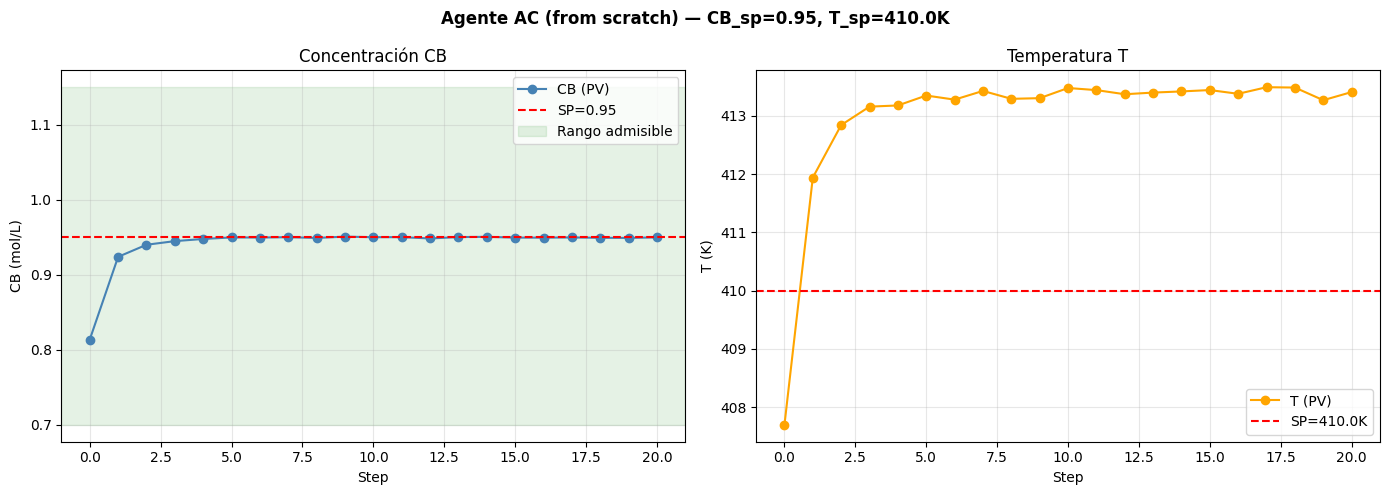

In [13]:
# ============ GRAFICAR ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(traj_CB, marker='o', color='steelblue', label='CB (PV)')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green', label='Rango admisible')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(traj_T, marker='o', color='orange', label='T (PV)')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Agente AC (from scratch) — CB_sp={CB_sp}, T_sp={T_sp}K', fontweight='bold')
plt.tight_layout()
plt.savefig('eval_transfer_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Comparación con Baselines del Informe 2015

In [ ]:
# ============ BASELINE: PID MANUAL DEL INFORME ============
def run_baseline_pid(reactor, CB_sp, T_sp, Kp_CB, Ki_CB, Kd_CB, Kp_T, Ki_T, Kd_T, n_steps=2000):
    """Simula el reactor con PID fijos (baselines del informe 2015)."""
    reactor.reset()
    integral_CB, integral_T = 0.0, 0.0
    prev_err_CB, prev_err_T = 0.0, 0.0
    dt = reactor.dt
    cb_hist, t_hist = [], []

    for _ in range(n_steps):
        meas = reactor.get_measurements()

        err_CB = CB_sp - meas['CB']
        integral_CB += err_CB * dt
        deriv_CB = (err_CB - prev_err_CB) / dt
        v_out = reactor.v_ss + Kp_CB * err_CB + Ki_CB * integral_CB + Kd_CB * deriv_CB
        v_out = np.clip(v_out, 50, 800)
        prev_err_CB = err_CB

        err_T = T_sp - meas['T']
        integral_T += err_T * dt
        deriv_T = (err_T - prev_err_T) / dt
        QK_out = reactor.QK_ss + Kp_T * err_T + Ki_T * integral_T + Kd_T * deriv_T
        QK_out = np.clip(QK_out, -8500, 0)
        prev_err_T = err_T

        pvs = reactor.simulate_step_multi([v_out, QK_out], dt)
        cb_hist.append(pvs[0])
        t_hist.append(pvs[1])

    return cb_hist, t_hist


# ============ CORRER BASELINES ============
CB_sp, T_sp = 0.95, 410.0

reactor_bl = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))

# Ajuste manual (informe sección 4.3)
cb_manual, t_manual = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=100, Ki_CB=1000, Kd_CB=0.01,
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

# Ziegler-Nichols CB + manual T
cb_zn, t_zn = run_baseline_pid(
    reactor_bl, CB_sp, T_sp,
    Kp_CB=1081.4, Ki_CB=1081.4/0.020, Kd_CB=0,  # ZN sin Kd (mejor resultado del informe)
    Kp_T=20, Ki_T=2000, Kd_T=0.0
)

print(f'Manual:  CB_final={cb_manual[-1]:.4f} (err={abs(cb_manual[-1]-CB_sp):.5f}), T_final={t_manual[-1]:.2f}')
print(f'Z-N:     CB_final={cb_zn[-1]:.4f} (err={abs(cb_zn[-1]-CB_sp):.5f}), T_final={t_zn[-1]:.2f}')

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Manual:  CB_final=0.9508 (err=0.00084), T_final=413.28
Z-N:     CB_final=0.9506 (err=0.00061), T_final=413.32


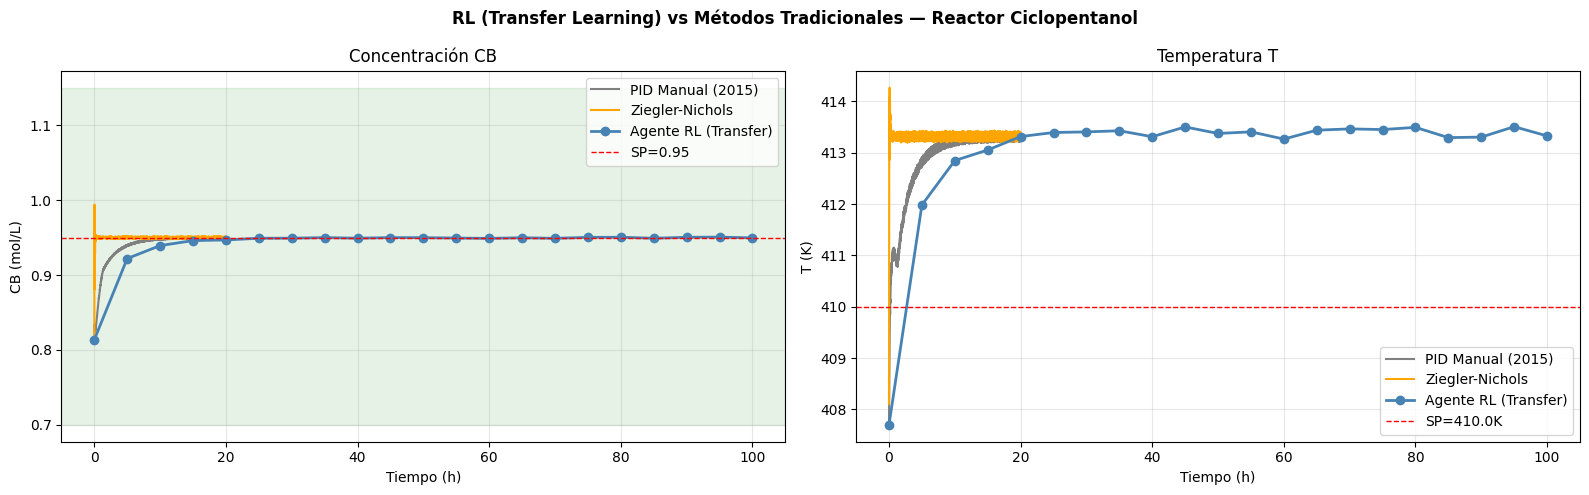

In [ ]:
# ============ COMPARAR TODOS ============
time_hours = np.arange(len(cb_manual)) * DT

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# CB
axes[0].plot(time_hours, cb_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[0].plot(time_hours, cb_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[0].plot(np.arange(len(traj_CB)) * (5.0),  # tiempo aprox por step
             traj_CB, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[0].axhline(CB_sp, color='red', linestyle='--', linewidth=1, label=f'SP={CB_sp}')
axes[0].axhspan(0.7, 1.15, alpha=0.1, color='green')
axes[0].set_title('Concentración CB')
axes[0].set_xlabel('Tiempo (h)')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# T
axes[1].plot(time_hours, t_manual, label='PID Manual (2015)', color='gray', linewidth=1.5)
axes[1].plot(time_hours, t_zn, label='Ziegler-Nichols', color='orange', linewidth=1.5)
axes[1].plot(np.arange(len(traj_T)) * (5.0),
             traj_T, label='Agente RL (Transfer)', color='steelblue', linewidth=2, marker='o')
axes[1].axhline(T_sp, color='red', linestyle='--', linewidth=1, label=f'SP={T_sp}K')
axes[1].set_title('Temperatura T')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RL (Transfer Learning) vs Métodos Tradicionales — Reactor Ciclopentanol', fontweight='bold')
plt.tight_layout()
plt.savefig('rl_vs_traditional_cyclopentanol.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Pruebas con otros SP (Grilla)

In [19]:
# ============ GRILLA DE SETPOINTS ============
CB_setpoints = [0.75, 0.85, 0.95, 1.05, 1.10]  # mol/L (rango admisible: 0.7-1.15)
T_setpoints  = [405, 408, 410, 412, 415]        # K

# ============ FUNCIÓN DE EVALUACIÓN ============
eval_config = trainer_config_prod.copy()
eval_config['n_episodes'] = 1
eval_config['use_wandb'] = False
eval_config['checkpoint_dir'] = 'checkpoints/eval_tmp'

reactor_eval2 = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
trainer_eval = ACTrainer(eval_config)
trainer_eval.env.proceso.connect_external_process(reactor_eval2)
trainer_eval.env.pid_controllers[0].output_limits = ACTUATOR_LIMITS[0]
trainer_eval.env.pid_controllers[1].output_limits = ACTUATOR_LIMITS[1]

# ============ FIX: PID bias en cada reset ============
_original_reset_eval = trainer_eval.env.reset

def reset_eval_with_bias(*args, **kwargs):
    result = _original_reset_eval(*args, **kwargs)
    for i, pid in enumerate(trainer_eval.env.pid_controllers):
        if i == 0:
            pid.kp = 50.0
            pid.ki = 500.0
            pid.kd = 0.01
            pid.integral = reactor_eval2.v_ss / pid.ki
        elif i == 1:
            pid.kp = 10.0
            pid.ki = 1000.0
            pid.kd = 0.0
            pid.integral = reactor_eval2.QK_ss / pid.ki
    return result

trainer_eval.env.reset = reset_eval_with_bias

trainer_eval.agent_ctrl.load(BEST_CHECKPOINT)
print('Agente cargado para evaluación')


def evaluar_sp(trainer, CB_sp, T_sp, max_steps=100):
    state = trainer.env.reset()[0]
    trainer.env.manipulable_setpoints = [CB_sp, T_sp]
    trainer.env._update_errors()
    state = trainer.env._get_observation()

    CB_hist, T_hist = [], []
    done = False
    step = 0

    while not done and step < max_steps:
        action = trainer.agent_ctrl.select_action(state, training=False)
        next_state, reward, terminated, truncated, info = trainer.env.step(action)
        done = terminated or truncated
        CB_hist.append(trainer.env.manipulable_pvs[0])
        T_hist.append(trainer.env.manipulable_pvs[1])
        state = next_state
        step += 1

    return np.array(CB_hist), np.array(T_hist)

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
AC Estocástico creado | role=ctrl | state=10 | action=6 | device=cpu
AC Agent cargado desde: /content/artifacts/model_ac_cyclopentanol_5k_V3:v3/agent_ctrl_best.pt
Agente cargado para evaluación


CB_sp=0.75 → CB_final=0.7437 (err=0.0063) | T_final=410.38 (err=0.38K)
CB_sp=0.85 → CB_final=0.8235 (err=0.0265) | T_final=410.81 (err=0.81K)
CB_sp=0.95 → CB_final=0.8880 (err=0.0620) | T_final=411.40 (err=1.40K)
CB_sp=1.05 → CB_final=0.9306 (err=0.1194) | T_final=412.42 (err=2.42K)
CB_sp=1.1 → CB_final=0.9441 (err=0.1559) | T_final=413.14 (err=3.14K)


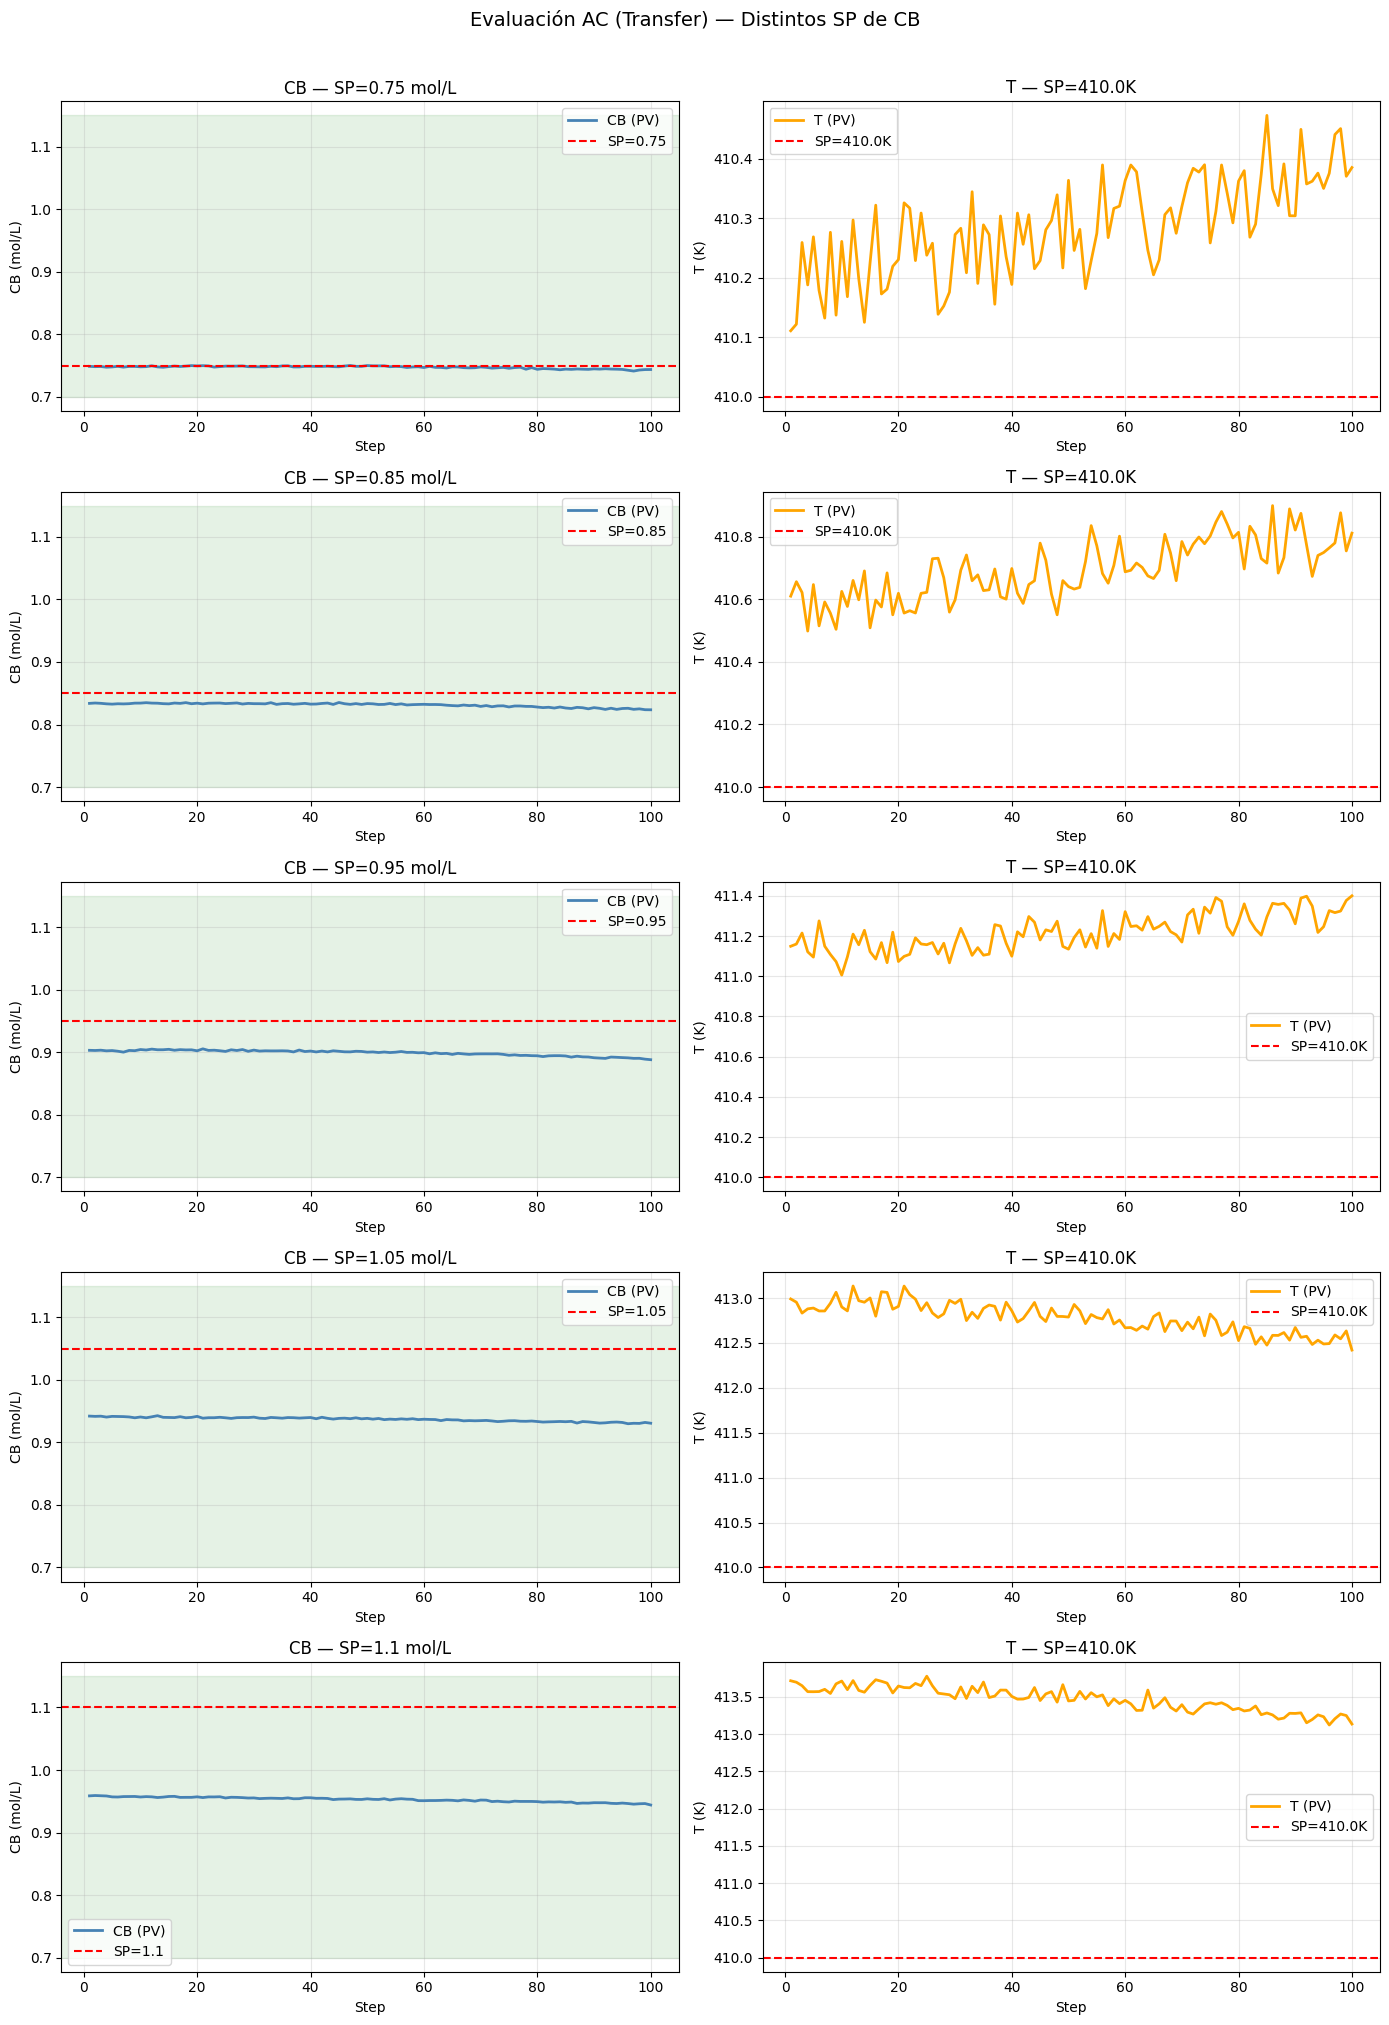

In [ ]:
# ============ EVALUAR Y GRAFICAR ============
fig, axes = plt.subplots(len(CB_setpoints), 2, figsize=(14, 4 * len(CB_setpoints)))

T_fijo = 410.0  # Temperatura fija para variar CB

for i, CB_sp in enumerate(CB_setpoints):
    CB_hist, T_hist = evaluar_sp(trainer_eval, CB_sp, T_fijo)
    steps = np.arange(1, len(CB_hist) + 1)

    ax_CB = axes[i, 0]
    ax_CB.plot(steps, CB_hist, color='steelblue', linewidth=2, label='CB (PV)')
    ax_CB.axhline(CB_sp, color='red', linestyle='--', linewidth=1.5, label=f'SP={CB_sp}')
    ax_CB.axhspan(0.7, 1.15, alpha=0.1, color='green')
    ax_CB.set_title(f'CB — SP={CB_sp} mol/L')
    ax_CB.set_xlabel('Step')
    ax_CB.set_ylabel('CB (mol/L)')
    ax_CB.legend()
    ax_CB.grid(True, alpha=0.3)

    ax_T = axes[i, 1]
    ax_T.plot(steps, T_hist, color='orange', linewidth=2, label='T (PV)')
    ax_T.axhline(T_fijo, color='red', linestyle='--', linewidth=1.5, label=f'SP={T_fijo}K')
    ax_T.set_title(f'T — SP={T_fijo}K')
    ax_T.set_xlabel('Step')
    ax_T.set_ylabel('T (K)')
    ax_T.legend()
    ax_T.grid(True, alpha=0.3)

    print(f'CB_sp={CB_sp} → CB_final={CB_hist[-1]:.4f} (err={abs(CB_hist[-1]-CB_sp):.4f}) | '
          f'T_final={T_hist[-1]:.2f} (err={abs(T_hist[-1]-T_fijo):.2f}K)')

plt.suptitle('Evaluación AC (Transfer) — Distintos SP de CB', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eval_transfer_CB_setpoints.png', dpi=150, bbox_inches='tight')
plt.show()

Con RL dinamico

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
t=10.0h | Nuevo SP: CB=0.8500, T=407.70K
t=20.0h | Nuevo SP: CB=0.9500, T=407.70K
t=30.0h | Nuevo SP: CB=0.7500, T=407.70K
t=40.0h | Nuevo SP: CB=1.0500, T=407.70K
t=50.0h | Nuevo SP: CB=0.8137, T=407.70K


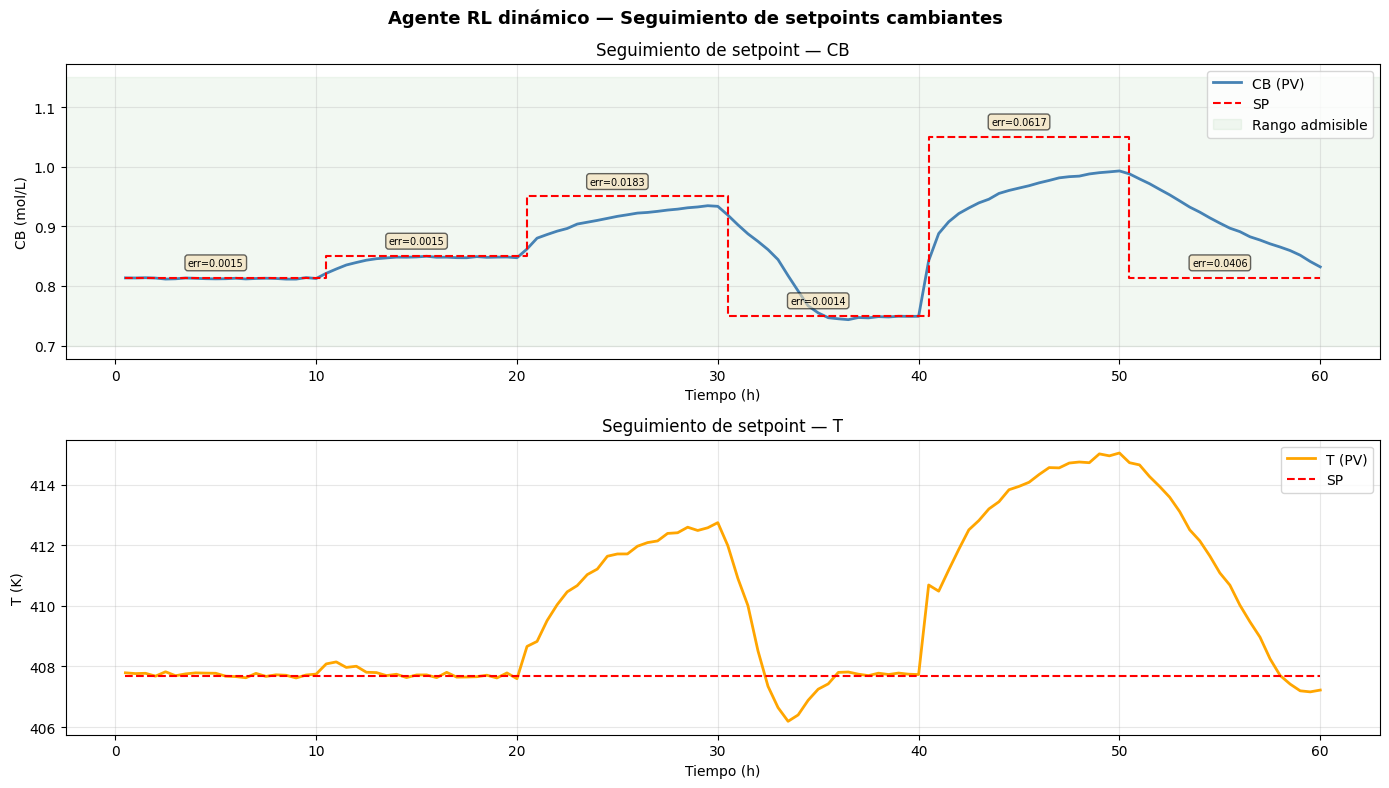


=== Resumen de seguimiento ===
t=[0-10]h | SP_CB=0.8137 | err_mean=0.0014 | err_max=0.0022
t=[10-20]h | SP_CB=0.8500 | err_mean=0.0017 | err_max=0.0027
t=[20-30]h | SP_CB=0.9500 | err_mean=0.0239 | err_max=0.0333
t=[30-40]h | SP_CB=0.7500 | err_mean=0.0032 | err_max=0.0066
t=[40-50]h | SP_CB=1.0500 | err_mean=0.0700 | err_max=0.0859
t=[50-60]h | SP_CB=0.8137 | err_mean=0.0604 | err_max=0.0916


In [32]:
# ============ SEGUIMIENTO DE SETPOINTS CAMBIANTES — RL DINÁMICO ============
# El SP cambia cada 10 horas. El agente ajusta Kp, Ki, Kd dinámicamente.

reactor_sp = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_sp.reset()

pid_controllers_sp = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers_sp[0].integral = reactor_sp.v_ss / pid_controllers_sp[0].ki
pid_controllers_sp[1].integral = reactor_sp.QK_ss / pid_controllers_sp[1].ki

apply_action_sp = ApplyAction(
    delta_percent_ctrl=0.05,
    pid_limits=[(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
    manipulable_ranges=MANIPULABLE_RANGES
)

# Secuencia de setpoints: cambiar CB cada 10h, T fijo
SP_SCHEDULE = [
    # (hora_inicio, CB_sp, T_sp)
    (0,   reactor_sp.CB_ss, reactor_sp.T_ss),  # Arrancar en SS
    (10,  0.85,             reactor_sp.T_ss),   # Subir CB
    (20,  0.95,             reactor_sp.T_ss),   # Subir más CB
    (30,  0.75,             reactor_sp.T_ss),   # Bajar CB
    (40,  1.05,             reactor_sp.T_ss),   # Subir CB bastante
    (50,  reactor_sp.CB_ss, reactor_sp.T_ss),   # Volver a SS
]

TOTAL_HOURS = 60
INNER_STEPS = 50  # 50 * DT = 0.5 horas por step del agente
N_AGENT_STEPS = int(TOTAL_HOURS / (INNER_STEPS * DT))

pvs = reactor_sp.get_initial_pvs()
sps = [SP_SCHEDULE[0][1], SP_SCHEDULE[0][2]]

error_integral = [0.0, 0.0]
error_prev = [sps[i] - pvs[i] for i in range(2)]

cb_hist, t_hist = [], []
sp_cb_hist, sp_t_hist = [], []
time_hist = []

sp_idx = 0

for step in range(N_AGENT_STEPS):
    current_time = step * INNER_STEPS * DT

    # Verificar si hay que cambiar el SP
    if sp_idx + 1 < len(SP_SCHEDULE) and current_time >= SP_SCHEDULE[sp_idx + 1][0]:
        sp_idx += 1
        sps = [SP_SCHEDULE[sp_idx][1], SP_SCHEDULE[sp_idx][2]]
        print(f't={current_time:.1f}h | Nuevo SP: CB={sps[0]:.4f}, T={sps[1]:.2f}K')

    # Construir observación para el agente
    errors = [sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i] * DT
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    # El agente decide los parámetros PID
    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action_sp.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers_sp]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers_sp[i].kp = kp
        pid_controllers_sp[i].ki = ki
        pid_controllers_sp[i].kd = kd

    # Inner loop: PID controla el reactor
    for inner in range(INNER_STEPS):
        meas = reactor_sp.get_measurements()
        v_out = pid_controllers_sp[0].compute(setpoint=sps[0], process_value=meas['CB'])
        qk_out = pid_controllers_sp[1].compute(setpoint=sps[1], process_value=meas['T'])
        pvs_new = reactor_sp.simulate_step_multi([v_out, qk_out], DT)

    pvs = [pvs_new[0], pvs_new[1]]
    cb_hist.append(pvs[0])
    t_hist.append(pvs[1])
    sp_cb_hist.append(sps[0])
    sp_t_hist.append(sps[1])
    time_hist.append(current_time + INNER_STEPS * DT)

# ============ GRAFICAR ============
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# CB
axes[0].plot(time_hist, cb_hist, color='steelblue', linewidth=2, label='CB (PV)')
axes[0].step(time_hist, sp_cb_hist, color='red', linestyle='--', linewidth=1.5, label='SP', where='post')
axes[0].axhspan(0.7, 1.15, alpha=0.05, color='green', label='Rango admisible')
axes[0].set_ylabel('CB (mol/L)')
axes[0].set_title('Seguimiento de setpoint — CB')
axes[0].set_xlabel('Tiempo (h)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Anotar errores en cada tramo
for idx in range(len(SP_SCHEDULE)):
    t_start = SP_SCHEDULE[idx][0]
    t_end = SP_SCHEDULE[idx + 1][0] if idx + 1 < len(SP_SCHEDULE) else TOTAL_HOURS
    sp_cb = SP_SCHEDULE[idx][1]
    # Filtrar datos en este tramo (últimos 20% para medir error en régimen)
    tramo_cb = [cb for t, cb in zip(time_hist, cb_hist) if t >= t_start + 0.8 * (t_end - t_start) and t < t_end]
    if tramo_cb:
        err = np.mean(np.abs(np.array(tramo_cb) - sp_cb))
        axes[0].text((t_start + t_end) / 2, sp_cb + 0.02, f'err={err:.4f}',
                     ha='center', fontsize=7, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# T
axes[1].plot(time_hist, t_hist, color='orange', linewidth=2, label='T (PV)')
axes[1].step(time_hist, sp_t_hist, color='red', linestyle='--', linewidth=1.5, label='SP', where='post')
axes[1].set_ylabel('T (K)')
axes[1].set_title('Seguimiento de setpoint — T')
axes[1].set_xlabel('Tiempo (h)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Agente RL dinámico — Seguimiento de setpoints cambiantes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('seguimiento_sp_cambiantes.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen
print('\n=== Resumen de seguimiento ===')
for idx in range(len(SP_SCHEDULE)):
    t_start = SP_SCHEDULE[idx][0]
    t_end = SP_SCHEDULE[idx + 1][0] if idx + 1 < len(SP_SCHEDULE) else TOTAL_HOURS
    sp_cb = SP_SCHEDULE[idx][1]
    tramo_cb = [cb for t, cb in zip(time_hist, cb_hist) if t >= t_start + 0.5 * (t_end - t_start) and t < t_end]
    if tramo_cb:
        err_mean = np.mean(np.abs(np.array(tramo_cb) - sp_cb))
        err_max = np.max(np.abs(np.array(tramo_cb) - sp_cb))
        print(f't=[{t_start:.0f}-{t_end:.0f}]h | SP_CB={sp_cb:.4f} | err_mean={err_mean:.4f} | err_max={err_max:.4f}')

## 10. Test de Robustez: Perturbación en CA0

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Perturbación: CA0 = 5.5 mol/L


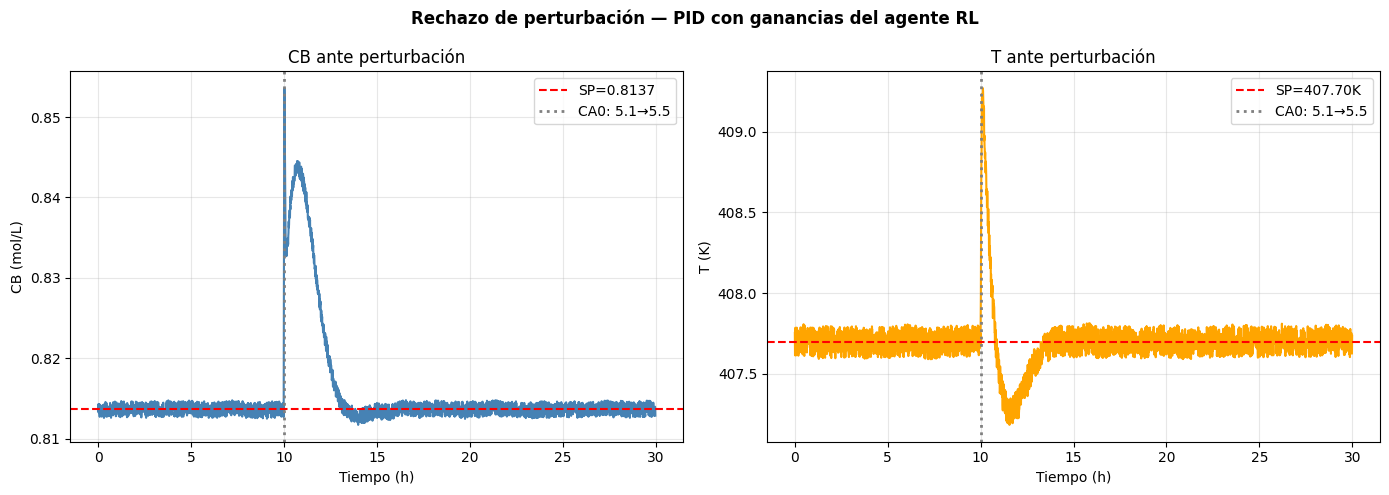

In [ ]:
# ============ TEST DE ROBUSTEZ — LOOP DIRECTO ============
reactor_rob = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_rob.reset()

pid_controllers = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers[0].integral = reactor_rob.v_ss / pid_controllers[0].ki
pid_controllers[1].integral = reactor_rob.QK_ss / pid_controllers[1].ki

CB_sp = reactor_rob.CB_ss
T_sp = reactor_rob.T_ss

N_STEPS = 3000  # 30 horas
PERTURB_STEP = 1000  # Perturbación a las 10 horas

cb_hist, t_hist = [], []

for step in range(N_STEPS):
    if step == PERTURB_STEP:
        reactor_rob.set_disturbance(CA0=5.5)

    meas = reactor_rob.get_measurements()
    v_out = pid_controllers[0].compute(setpoint=CB_sp, process_value=meas['CB'])
    qk_out = pid_controllers[1].compute(setpoint=T_sp, process_value=meas['T'])
    pvs = reactor_rob.simulate_step_multi([v_out, qk_out], DT)
    cb_hist.append(pvs[0])
    t_hist.append(pvs[1])

# --- Graficar ---
time_h = np.arange(N_STEPS) * DT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(time_h, cb_hist, color='steelblue', linewidth=1.5)
axes[0].axhline(CB_sp, color='red', linestyle='--', label=f'SP={CB_sp:.4f}')
axes[0].axvline(PERTURB_STEP * DT, color='gray', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
axes[0].set_title('CB ante perturbación')
axes[0].set_xlabel('Tiempo (h)')
axes[0].set_ylabel('CB (mol/L)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_h, t_hist, color='orange', linewidth=1.5)
axes[1].axhline(T_sp, color='red', linestyle='--', label=f'SP={T_sp:.2f}K')
axes[1].axvline(PERTURB_STEP * DT, color='gray', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
axes[1].set_title('T ante perturbación')
axes[1].set_xlabel('Tiempo (h)')
axes[1].set_ylabel('T (K)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Rechazo de perturbación — PID con ganancias del agente RL', fontweight='bold')
plt.tight_layout()
plt.savefig('robustez_perturbacion_loop_directo.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============ COMPARACIÓN DE RECHAZO DE PERTURBACIÓN ============
# PID Manual (informe 2015) vs Ziegler-Nichols (informe 2015) vs PID con ganancias RL
# Todos con el MISMO simulador no lineal, misma perturbación CA0: 5.1 → 5.5

def run_perturbation_test(reactor_class, dt, actuator_limits,
                          Kp_CB, Ki_CB, Kd_CB, Kp_T, Ki_T, Kd_T,
                          n_steps=3000, perturb_step=1000, CA0_new=5.5):
    """Corre una simulación con PID fijo y perturbación escalón en CA0."""
    reactor = reactor_class(dt=dt, control_limits=(actuator_limits[0], actuator_limits[1]))
    reactor.reset()

    integral_CB, integral_T = 0.0, 0.0
    prev_err_CB, prev_err_T = 0.0, 0.0

    # Inicializar integrales en SS (bias)
    integral_CB = reactor.v_ss / Ki_CB if Ki_CB != 0 else 0.0
    integral_T = reactor.QK_ss / Ki_T if Ki_T != 0 else 0.0

    CB_sp = reactor.CB_ss
    T_sp = reactor.T_ss

    cb_hist, t_hist = [], []

    for step in range(n_steps):
        if step == perturb_step:
            reactor.set_disturbance(CA0=CA0_new)

        meas = reactor.get_measurements()

        err_CB = CB_sp - meas['CB']
        integral_CB += err_CB * dt
        deriv_CB = (err_CB - prev_err_CB) / dt
        v_out = reactor.v_ss + Kp_CB * err_CB + Ki_CB * (integral_CB - reactor.v_ss / Ki_CB) + Kd_CB * deriv_CB if Ki_CB != 0 else reactor.v_ss + Kp_CB * err_CB + Kd_CB * deriv_CB
        v_out = np.clip(v_out, actuator_limits[0][0], actuator_limits[0][1])
        prev_err_CB = err_CB

        err_T = T_sp - meas['T']
        integral_T += err_T * dt
        deriv_T = (err_T - prev_err_T) / dt
        QK_out = reactor.QK_ss + Kp_T * err_T + Ki_T * (integral_T - reactor.QK_ss / Ki_T) + Kd_T * deriv_T if Ki_T != 0 else reactor.QK_ss + Kp_T * err_T + Kd_T * deriv_T
        QK_out = np.clip(QK_out, actuator_limits[1][0], actuator_limits[1][1])
        prev_err_T = err_T

        pvs = reactor.simulate_step_multi([v_out, QK_out], dt)
        cb_hist.append(pvs[0])
        t_hist.append(pvs[1])

    return cb_hist, t_hist, CB_sp, T_sp




In [15]:
# ============ CORRER LAS 3 CONFIGURACIONES ============
N_STEPS = 3000
PERTURB_STEP = 1000

# 1) PID Manual del informe 2015 (sección 4.3)
cb_manual, t_manual, CB_sp, T_sp = run_perturbation_test(
    CyclopentanolReactor, DT, ACTUATOR_LIMITS,
    Kp_CB=100, Ki_CB=1000, Kd_CB=0.01,
    Kp_T=20, Ki_T=2000, Kd_T=0.0,
    n_steps=N_STEPS, perturb_step=PERTURB_STEP
)

# 2) PID Ziegler-Nichols del informe 2015 (sin Kd, mejor resultado)
cb_zn, t_zn, _, _ = run_perturbation_test(
    CyclopentanolReactor, DT, ACTUATOR_LIMITS,
    Kp_CB=1081.4, Ki_CB=1081.4/0.020, Kd_CB=0.0,
    Kp_T=20, Ki_T=2000, Kd_T=0.0,
    n_steps=N_STEPS, perturb_step=PERTURB_STEP
)

# 3) PID con ganancias del agente RL (las que usa la celda 24)
cb_rl, t_rl, _, _ = run_perturbation_test(
    CyclopentanolReactor, DT, ACTUATOR_LIMITS,
    Kp_CB=50.0, Ki_CB=500.0, Kd_CB=0.01,
    Kp_T=10.0, Ki_T=1000.0, Kd_T=0.0,
    n_steps=N_STEPS, perturb_step=PERTURB_STEP
)

print(f'SS: CB_sp={CB_sp:.4f}, T_sp={T_sp:.2f}K')
print(f'Manual:  CB err_max={max(abs(np.array(cb_manual[PERTURB_STEP:])-CB_sp)):.5f}, T err_max={max(abs(np.array(t_manual[PERTURB_STEP:])-T_sp)):.3f}K')
print(f'Z-N:     CB err_max={max(abs(np.array(cb_zn[PERTURB_STEP:])-CB_sp)):.5f}, T err_max={max(abs(np.array(t_zn[PERTURB_STEP:])-T_sp)):.3f}K')
print(f'RL:      CB err_max={max(abs(np.array(cb_rl[PERTURB_STEP:])-CB_sp)):.5f}, T err_max={max(abs(np.array(t_rl[PERTURB_STEP:])-T_sp)):.3f}K')




  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Perturbación: CA0 = 5.5 mol/L
  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Perturbación: CA0 = 5.5 mol/L
  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Perturbación: CA0 = 5.5 mol/

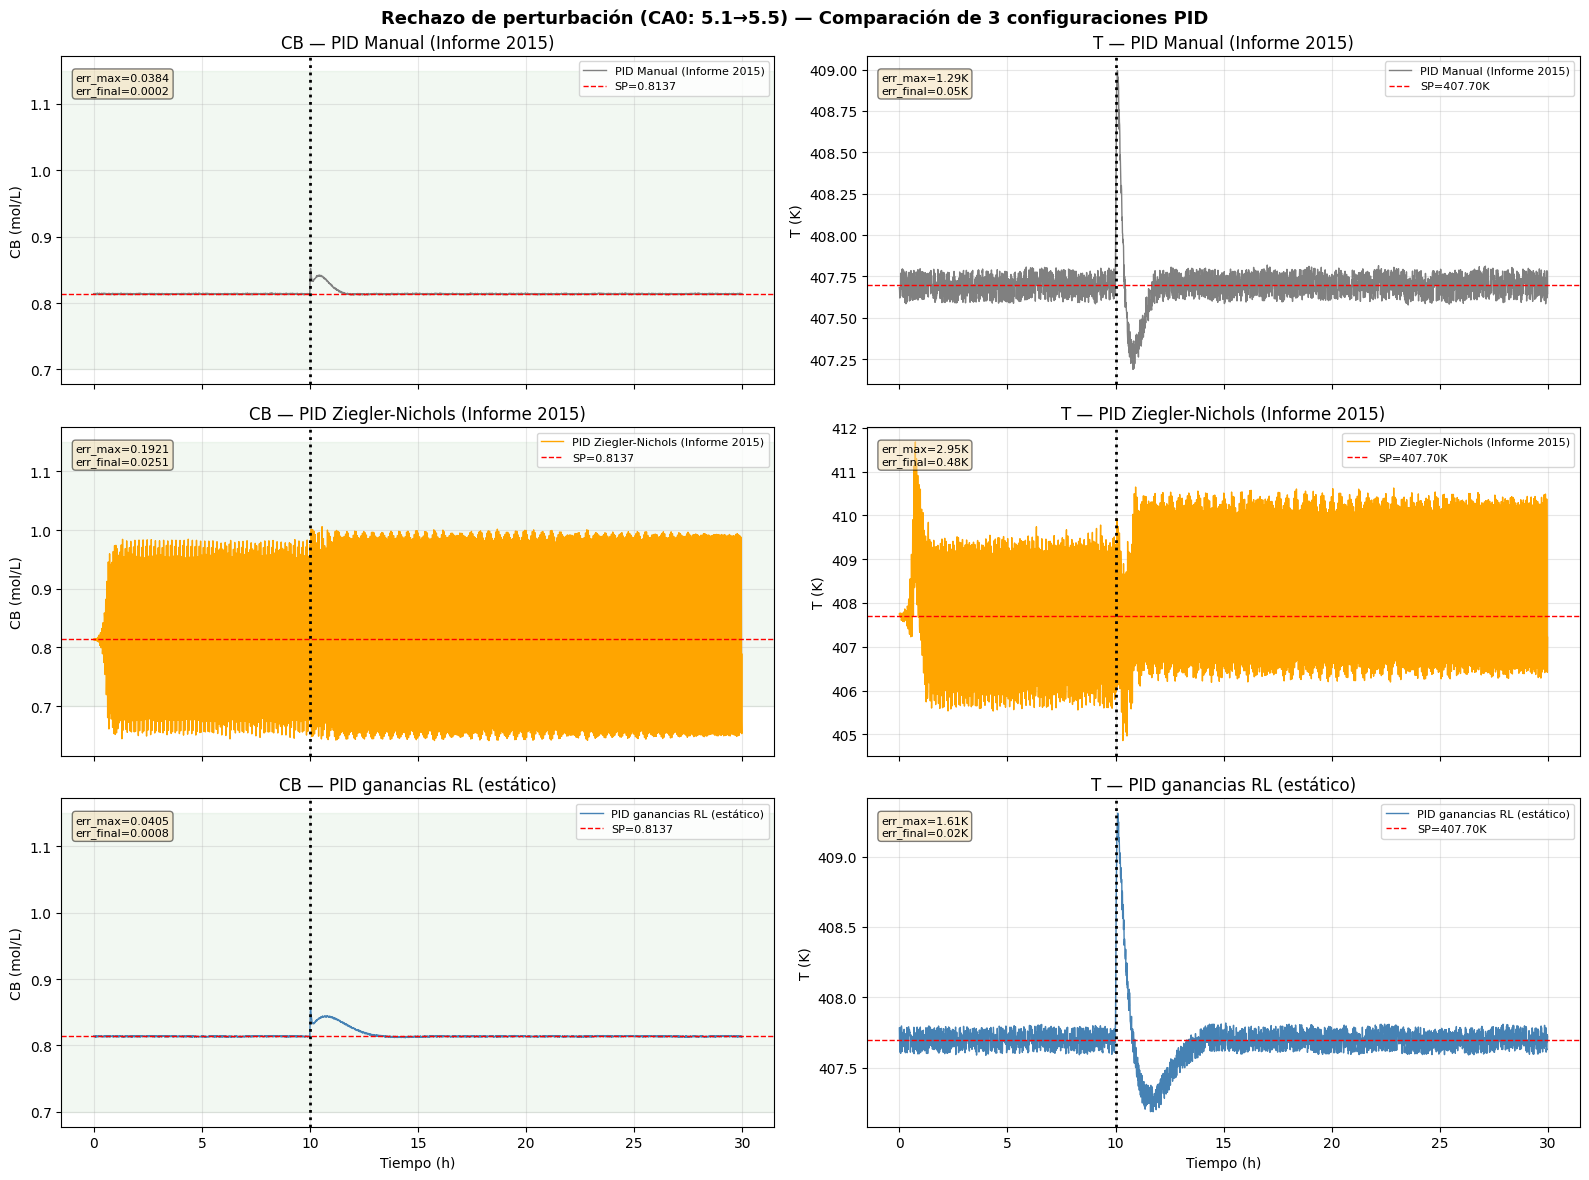

In [17]:
# ============ GRAFICAR COMPARACIÓN ============
time_h = np.arange(N_STEPS) * DT

configs = [
    ('PID Manual (Informe 2015)', cb_manual, t_manual, 'gray'),
    ('PID Ziegler-Nichols (Informe 2015)', cb_zn, t_zn, 'orange'),
    ('PID ganancias RL (estático)', cb_rl, t_rl, 'steelblue'),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

for i, (label, cb, t, color) in enumerate(configs):
    # CB
    axes[i, 0].plot(time_h, cb, color=color, linewidth=1.0, label=label)
    axes[i, 0].axhline(CB_sp, color='red', linestyle='--', linewidth=1, label=f'SP={CB_sp:.4f}')
    axes[i, 0].axvline(PERTURB_STEP * DT, color='black', linestyle=':', linewidth=2)
    axes[i, 0].axhspan(0.7, 1.15, alpha=0.05, color='green')
    axes[i, 0].set_ylabel('CB (mol/L)')
    axes[i, 0].set_title(f'CB — {label}')
    axes[i, 0].legend(loc='upper right', fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    # Calcular métricas post-perturbación
    cb_post = np.array(cb[PERTURB_STEP:])
    cb_err_max = np.max(np.abs(cb_post - CB_sp))
    cb_err_final = abs(cb[-1] - CB_sp)
    axes[i, 0].text(0.02, 0.95, f'err_max={cb_err_max:.4f}\nerr_final={cb_err_final:.4f}',
                     transform=axes[i, 0].transAxes, fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # T
    axes[i, 1].plot(time_h, t, color=color, linewidth=1.0, label=label)
    axes[i, 1].axhline(T_sp, color='red', linestyle='--', linewidth=1, label=f'SP={T_sp:.2f}K')
    axes[i, 1].axvline(PERTURB_STEP * DT, color='black', linestyle=':', linewidth=2)
    axes[i, 1].set_ylabel('T (K)')
    axes[i, 1].set_title(f'T — {label}')
    axes[i, 1].legend(loc='upper right', fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

    t_post = np.array(t[PERTURB_STEP:])
    t_err_max = np.max(np.abs(t_post - T_sp))
    t_err_final = abs(t[-1] - T_sp)
    axes[i, 1].text(0.02, 0.95, f'err_max={t_err_max:.2f}K\nerr_final={t_err_final:.2f}K',
                     transform=axes[i, 1].transAxes, fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[2, 0].set_xlabel('Tiempo (h)')
axes[2, 1].set_xlabel('Tiempo (h)')

plt.suptitle('Rechazo de perturbación (CA0: 5.1→5.5) — Comparación de 3 configuraciones PID',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('perturbacion_comparativa_3subplots.png', dpi=150, bbox_inches='tight')
plt.show()

Grafico con agente ACTIVO

  Simulador de Reactor Ciclopentanol creado
   Temperatura alimentación: 403.0 K
   Concentración alimentación: 5.1 mol/L
   Límites v: [50.0, 800.0] L/h
   Límites QK: [-8500.0, 0.0] kJ/h
   Estado estacionario: CA=1.1061342294333978, CB=0.813677423834702, T=407.6979422715857
   Paso de tiempo: 0.01 h
Step   0 | CB=0.8125 | T=407.71K | kp_CB=49.00 ki_CB=499.0 | kp_T=9.00 ki_T=999.0
Step  19 | CB=0.8134 | T=407.66K | kp_CB=30.00 ki_CB=480.0 | kp_T=0.01 ki_T=980.0
Perturbación: CA0 = 5.5 mol/L
Step  20 | CB=0.8397 | T=408.38K | kp_CB=29.00 ki_CB=479.0 | kp_T=0.01 ki_T=979.0
Step  21 | CB=0.8417 | T=407.52K | kp_CB=28.00 ki_CB=478.0 | kp_T=0.01 ki_T=978.0
Step  25 | CB=0.8138 | T=407.65K | kp_CB=24.00 ki_CB=474.0 | kp_T=0.01 ki_T=974.0
Step  59 | CB=0.8121 | T=407.70K | kp_CB=0.01 ki_CB=440.0 | kp_T=0.01 ki_T=940.0

RL dinámico: CB_final=0.8121 (err=0.0016)
RL dinámico: T_final=407.70K (err=0.01K)


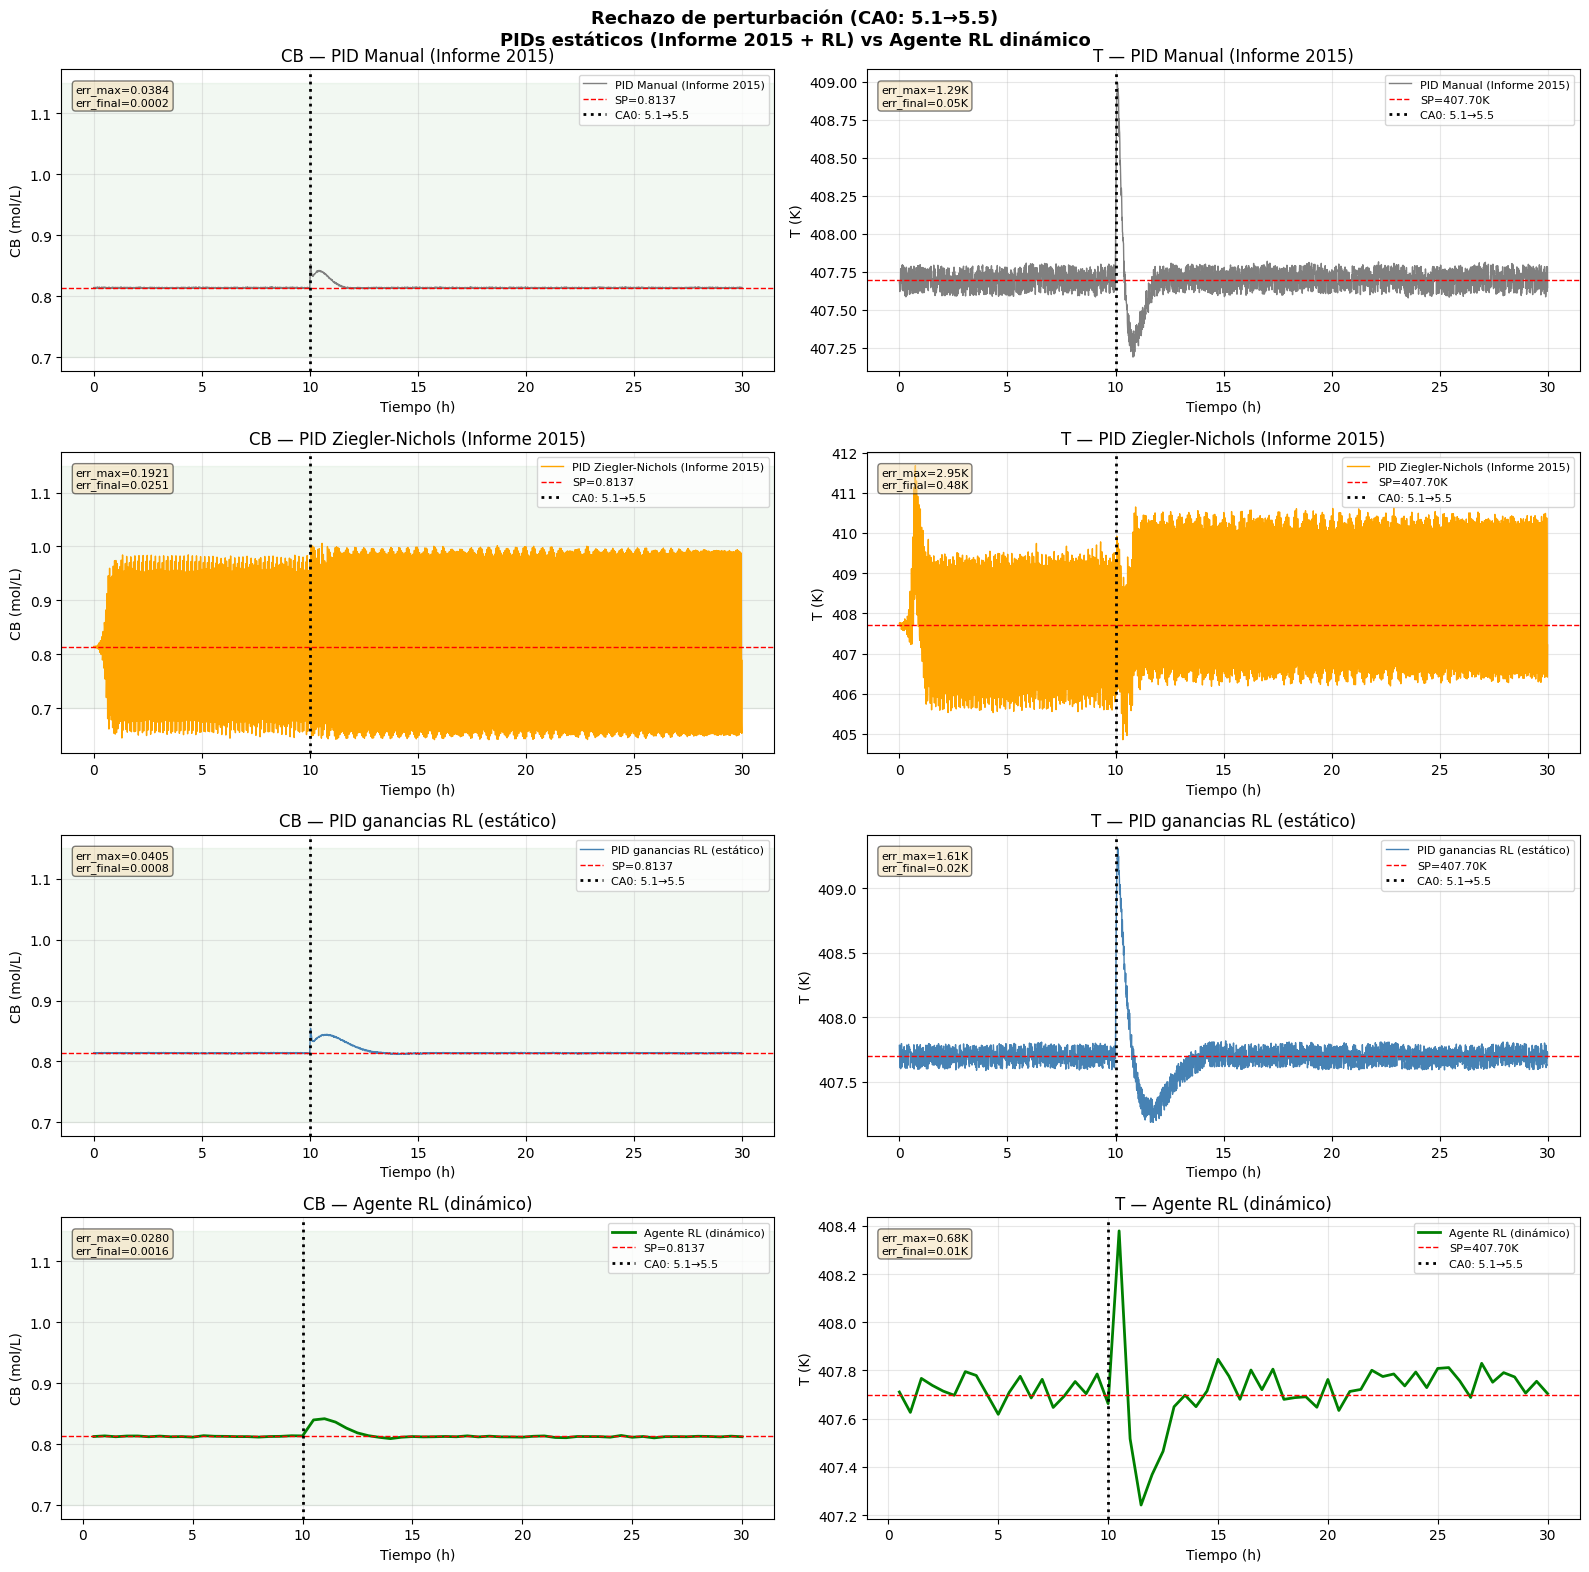

In [31]:
# ============ RL DINÁMICO — LOOP DIRECTO CON AGENTE ============
# El agente ajusta Kp, Ki, Kd cada N inner steps (como en la celda 13)
# La simulación se hace directo sobre el reactor, no via env.step()

reactor_dyn = CyclopentanolReactor(dt=DT, control_limits=(ACTUATOR_LIMITS[0], ACTUATOR_LIMITS[1]))
reactor_dyn.reset()

pid_controllers_dyn = [
    PIDController(kp=50.0, ki=500.0, kd=0.01, dt=DT, output_limits=ACTUATOR_LIMITS[0]),
    PIDController(kp=10.0, ki=1000.0, kd=0.0,  dt=DT, output_limits=ACTUATOR_LIMITS[1]),
]
pid_controllers_dyn[0].integral = reactor_dyn.v_ss / pid_controllers_dyn[0].ki
pid_controllers_dyn[1].integral = reactor_dyn.QK_ss / pid_controllers_dyn[1].ki

apply_action_dyn = ApplyAction(
    delta_percent_ctrl=0.05,
    pid_limits=[(0.01, 500.0), (0.0, 5000.0), (0.0, 10.0)],
    manipulable_ranges=MANIPULABLE_RANGES
)

CB_sp_dyn = reactor_dyn.CB_ss
T_sp_dyn = reactor_dyn.T_ss
sps = [CB_sp_dyn, T_sp_dyn]
pvs = reactor_dyn.get_initial_pvs()

error_integral = [0.0, 0.0]
error_prev = [sps[i] - pvs[i] for i in range(2)]

cb_rl_dyn, t_rl_dyn = [], []

N_AGENT_STEPS = 60       # Steps del agente
INNER_STEPS = 50          # Inner steps del PID por cada step del agente
PERTURB_AGENT_STEP = 20  # Perturbación en step 20 del agente

for step in range(N_AGENT_STEPS):
    if step == PERTURB_AGENT_STEP:
        reactor_dyn.set_disturbance(CA0=5.5)

    # Construir observación para el agente
    errors = [sps[i] - pvs[i] for i in range(2)]
    for i in range(2):
        error_integral[i] += errors[i] * DT
    error_derivative = [errors[i] - error_prev[i] for i in range(2)]
    error_prev = errors.copy()

    state = np.array([
        pvs[0], sps[0], errors[0], error_integral[0], error_derivative[0],
        pvs[1], sps[1], errors[1], error_integral[1], error_derivative[1],
    ], dtype=np.float32)

    # El agente decide los parámetros PID
    action = agent_eval.select_action(state, training=False)
    pid_params = apply_action_dyn.translate(
        action=action, agent_type='ctrl', action_type='continuous',
        current_values=[(p.kp, p.ki, p.kd) for p in pid_controllers_dyn]
    )
    for i, (kp, ki, kd) in enumerate(pid_params):
        pid_controllers_dyn[i].kp = kp
        pid_controllers_dyn[i].ki = ki
        pid_controllers_dyn[i].kd = kd

    # Inner loop: PID controla el reactor directamente
    for inner in range(INNER_STEPS):
        meas = reactor_dyn.get_measurements()
        v_out = pid_controllers_dyn[0].compute(setpoint=sps[0], process_value=meas['CB'])
        qk_out = pid_controllers_dyn[1].compute(setpoint=sps[1], process_value=meas['T'])
        pvs_new = reactor_dyn.simulate_step_multi([v_out, qk_out], DT)

    pvs = [pvs_new[0], pvs_new[1]]
    cb_rl_dyn.append(pvs[0])
    t_rl_dyn.append(pvs[1])

    if step in [0, PERTURB_AGENT_STEP-1, PERTURB_AGENT_STEP, PERTURB_AGENT_STEP+1,
                PERTURB_AGENT_STEP+5, N_AGENT_STEPS-1]:
        print(f'Step {step:3d} | CB={pvs[0]:.4f} | T={pvs[1]:.2f}K | '
              f'kp_CB={pid_controllers_dyn[0].kp:.2f} ki_CB={pid_controllers_dyn[0].ki:.1f} | '
              f'kp_T={pid_controllers_dyn[1].kp:.2f} ki_T={pid_controllers_dyn[1].ki:.1f}')

print(f'\nRL dinámico: CB_final={cb_rl_dyn[-1]:.4f} (err={abs(cb_rl_dyn[-1]-CB_sp_dyn):.4f})')
print(f'RL dinámico: T_final={t_rl_dyn[-1]:.2f}K (err={abs(t_rl_dyn[-1]-T_sp_dyn):.2f}K)')


# ============ GRAFICAR 4 SUBPLOTS (CORREGIDO) ============
time_h = np.arange(N_STEPS) * DT
# Tiempo del RL dinámico: cada agent step = INNER_STEPS * DT horas
time_rl_h = np.arange(1, N_AGENT_STEPS + 1) * INNER_STEPS * DT

configs = [
    ('PID Manual (Informe 2015)',          cb_manual,  t_manual,  'gray',      time_h,    PERTURB_STEP * DT,                CB_sp,     T_sp,     PERTURB_STEP),
    ('PID Ziegler-Nichols (Informe 2015)', cb_zn,      t_zn,      'orange',    time_h,    PERTURB_STEP * DT,                CB_sp,     T_sp,     PERTURB_STEP),
    ('PID ganancias RL (estático)',        cb_rl,      t_rl,      'steelblue', time_h,    PERTURB_STEP * DT,                CB_sp,     T_sp,     PERTURB_STEP),
    ('Agente RL (dinámico)',               cb_rl_dyn,  t_rl_dyn,  'green',     time_rl_h, PERTURB_AGENT_STEP * INNER_STEPS * DT, CB_sp_dyn, T_sp_dyn, PERTURB_AGENT_STEP),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for i, (label, cb, t, color, x_axis, perturb_x, sp_cb, sp_t, p_idx) in enumerate(configs):
    lw = 2.0 if i == 3 else 1.0

    # --- CB ---
    axes[i, 0].plot(x_axis, cb, color=color, linewidth=lw, label=label)
    axes[i, 0].axhline(sp_cb, color='red', linestyle='--', linewidth=1, label=f'SP={sp_cb:.4f}')
    axes[i, 0].axvline(perturb_x, color='black', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
    axes[i, 0].axhspan(0.7, 1.15, alpha=0.05, color='green')
    axes[i, 0].set_ylabel('CB (mol/L)')
    axes[i, 0].set_title(f'CB — {label}')
    axes[i, 0].set_xlabel('Tiempo (h)')
    axes[i, 0].legend(loc='upper right', fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    cb_post = np.array(cb[p_idx:])
    cb_err_max = np.max(np.abs(cb_post - sp_cb))
    cb_err_final = abs(cb[-1] - sp_cb)
    axes[i, 0].text(0.02, 0.95, f'err_max={cb_err_max:.4f}\nerr_final={cb_err_final:.4f}',
                     transform=axes[i, 0].transAxes, fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # --- T ---
    axes[i, 1].plot(x_axis, t, color=color, linewidth=lw, label=label)
    axes[i, 1].axhline(sp_t, color='red', linestyle='--', linewidth=1, label=f'SP={sp_t:.2f}K')
    axes[i, 1].axvline(perturb_x, color='black', linestyle=':', linewidth=2, label='CA0: 5.1→5.5')
    axes[i, 1].set_ylabel('T (K)')
    axes[i, 1].set_title(f'T — {label}')
    axes[i, 1].set_xlabel('Tiempo (h)')
    axes[i, 1].legend(loc='upper right', fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

    t_post = np.array(t[p_idx:])
    t_err_max = np.max(np.abs(t_post - sp_t))
    t_err_final = abs(t[-1] - sp_t)
    axes[i, 1].text(0.02, 0.95, f'err_max={t_err_max:.2f}K\nerr_final={t_err_final:.2f}K',
                     transform=axes[i, 1].transAxes, fontsize=8, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Rechazo de perturbación (CA0: 5.1→5.5)\nPIDs estáticos (Informe 2015 + RL) vs Agente RL dinámico',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('perturbacion_comparativa_4subplots.png', dpi=150, bbox_inches='tight')
plt.show()